STUDENT EXAM PASS PREDICTION SYSTEM

Import Libraries

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

LOAD DATASET

In [45]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Students Performance .csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (145, 15)
  Student_ID Student_Age     Sex High_School_Type Scholarship Additional_Work  \
0   STUDENT1       19-22    Male            Other         50%             Yes   
1   STUDENT2       19-22    Male            Other         50%             Yes   
2   STUDENT3       19-22    Male            State         50%              No   
3   STUDENT4          18  Female          Private         50%             Yes   
4   STUDENT5       19-22    Male          Private         50%              No   

  Sports_activity Transportation  Weekly_Study_Hours Attendance Reading Notes  \
0              No        Private                   0     Always     Yes   Yes   
1              No        Private                   0     Always     Yes    No   
2              No        Private                   2      Never      No    No   
3              No            Bus                   2     Always      No   Yes   
4              No            Bus                  12     Always     Yes    No   

 

 DATA CLEANING

In [46]:
print("\nMissing Values")
print(df.isnull().sum())

df.drop_duplicates(inplace=True)


Missing Values
Student_ID            0
Student_Age           0
Sex                   0
High_School_Type      0
Scholarship           1
Additional_Work       0
Sports_activity       0
Transportation        0
Weekly_Study_Hours    0
Attendance            0
Reading               0
Notes                 0
Listening_in_Class    0
Project_work          0
Grade                 0
dtype: int64


DESCRIPTIVE STATISTICS

In [48]:
print("\nAverage Weekly Study Hours:")
print(df["Weekly_Study_Hours"].mean())

print("\nGender Distribution")
print(df["Sex"].value_counts())


Average Weekly Study Hours:
2.331034482758621

Gender Distribution
Sex
Male      87
Female    58
Name: count, dtype: int64


In [61]:
df['Pass_Fail'] = df['Grade'].apply(lambda x: 0 if x == 0 else 1)

print('\nUnique Grades and their counts:')
print(df['Grade'].value_counts())

print('\nPass vs Fail Distribution (after redefinition):')
print(df['Pass_Fail'].value_counts())


Unique Grades and their counts:
Grade
0    35
1    24
2    21
4    17
6    17
5    13
3    10
7     8
Name: count, dtype: int64

Pass vs Fail Distribution (after redefinition):
Pass_Fail
1    110
0     35
Name: count, dtype: int64


In [62]:
X = df.drop(
    ["Pass_Fail"],
    axis=1
)

y = df["Pass_Fail"]

# Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# Model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Probability
y_prob = model.predict_proba(X_test)[:,1]

print("Model training complete. Proceeding to evaluation...")

Model training complete. Proceeding to evaluation...


In [70]:
print("\nAccuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("F1 Score:",f1_score(y_test, y_pred))
print("ROC AUC:",roc_auc_score(y_test, y_prob))
print("\nClassification Report")
print(classification_report(y_test, y_pred))


Accuracy: 0.9310344827586207
Precision: 1.0
Recall: 0.9230769230769231
F1 Score: 0.96
ROC AUC: 1.0

Classification Report
              precision    recall  f1-score   support

           0       0.60      1.00      0.75         3
           1       1.00      0.92      0.96        26

    accuracy                           0.93        29
   macro avg       0.80      0.96      0.85        29
weighted avg       0.96      0.93      0.94        29



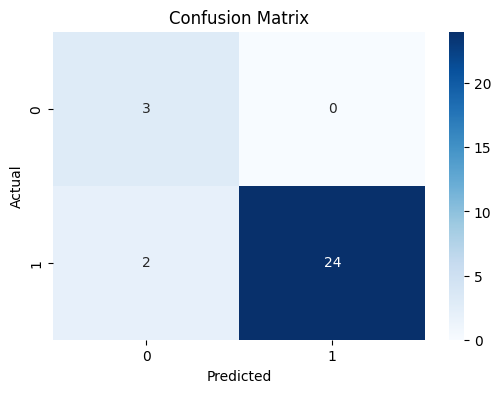

In [66]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

VISUALIZATION

Pass vs Fail

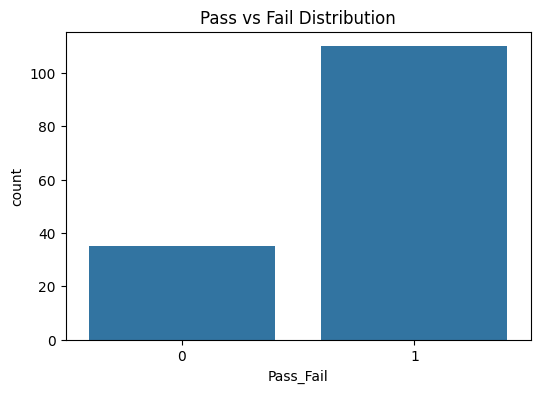

In [67]:
plt.figure(figsize=(6,4))
sns.countplot(x="Pass_Fail", data=df)
plt.title("Pass vs Fail Distribution")
plt.show()

Gender Distribution

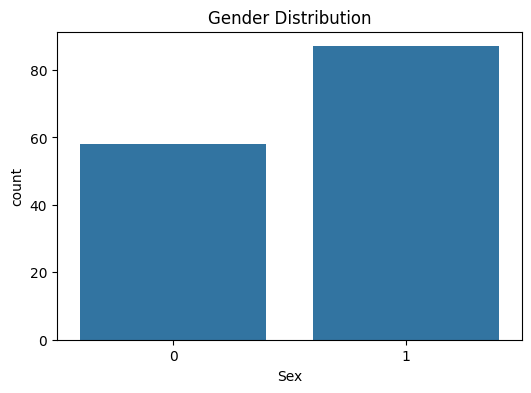

In [71]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", data=df)
plt.title("Gender Distribution")
plt.show()

Study Hours Distribution

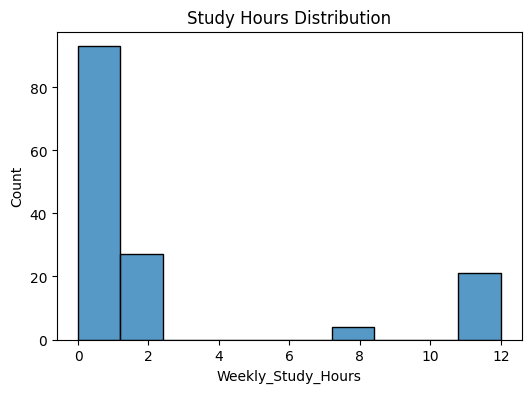

In [69]:
plt.figure(figsize=(6,4))
sns.histplot(df["Weekly_Study_Hours"], bins=10)
plt.title("Study Hours Distribution")
plt.show()

Attendance Distribution

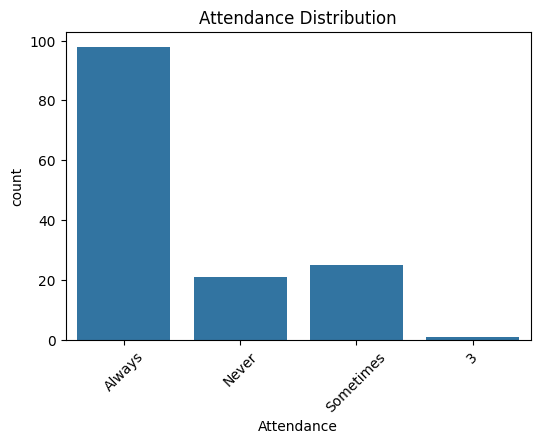

In [54]:
plt.figure(figsize=(6,4))
sns.countplot(x="Attendance", data=df)
plt.title("Attendance Distribution")
plt.xticks(rotation=45)
plt.show()

Grade Distribution

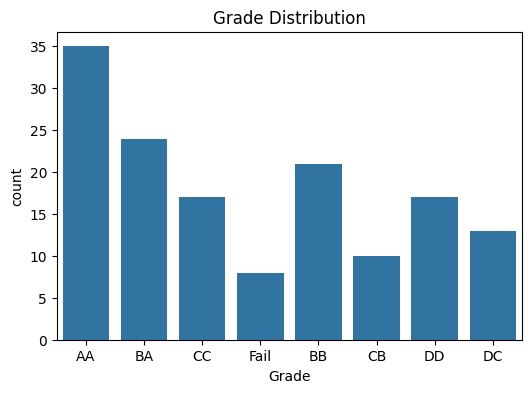

In [55]:
plt.figure(figsize=(6,4))
sns.countplot(x="Grade", data=df)
plt.title("Grade Distribution")
plt.show()

Encoding

In [73]:
le = LabelEncoder()

for col in df.columns:
    # Only encode object type columns, excluding 'Student_ID' if it still exists and was not meant to be encoded
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

# Remove Student ID only if it exists in the DataFrame
if 'Student_ID' in df.columns:
    df.drop("Student_ID", axis=1, inplace=True)
    print("Student_ID column dropped.")
else:
    print("Student_ID column not found in DataFrame (already dropped or never existed).")

Student_ID column not found in DataFrame (already dropped or never existed).


Correlation Heatmap

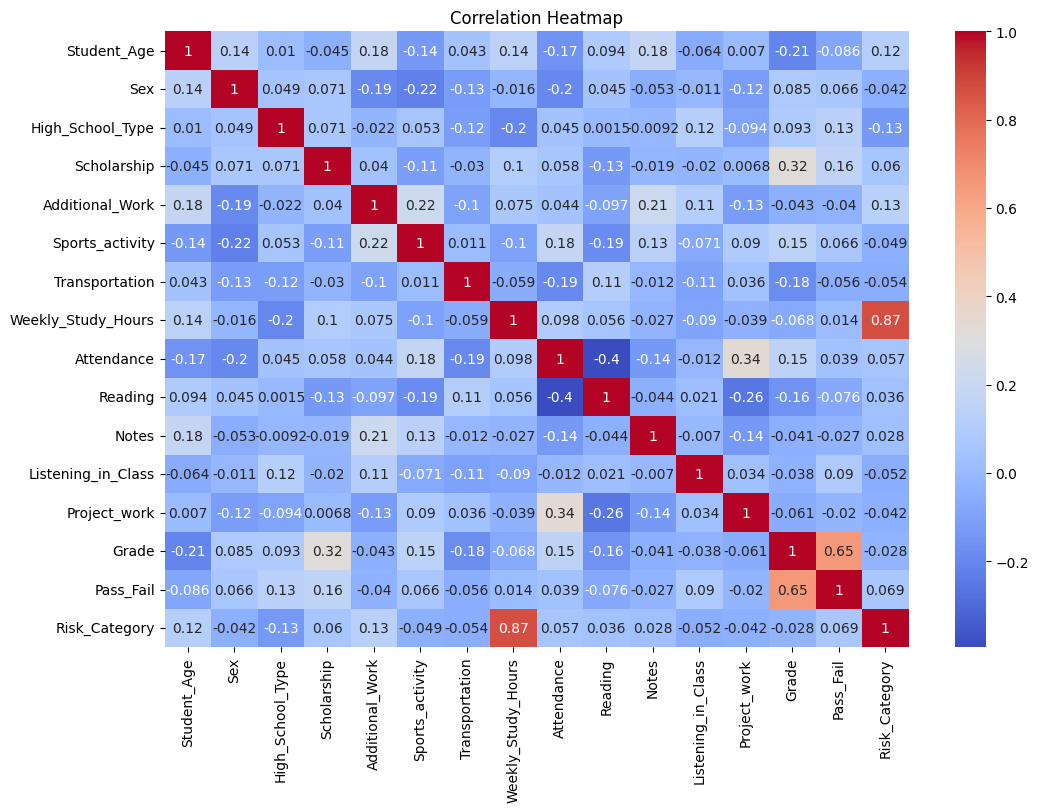

In [74]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()



Risk Analysis

In [75]:
def risk_level(row):

    if row["Weekly_Study_Hours"] <= 2:
        return "High Risk"

    elif row["Weekly_Study_Hours"] <= 8:
        return "Medium Risk"

    else:
        return "Low Risk"

df["Risk_Category"] = df.apply(
    risk_level,
    axis=1
)

print("\nRisk Category Count")
print(df["Risk_Category"].value_counts())

# Encode Risk Category
df["Risk_Category"] = LabelEncoder().fit_transform(
    df["Risk_Category"]
)


Risk Category Count
Risk_Category
High Risk      120
Low Risk        21
Medium Risk      4
Name: count, dtype: int64


Logistic Regression

In [76]:
X = df.drop(
    ["Pass_Fail"],
    axis=1
)

y = df["Pass_Fail"]

# Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# Model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Probability
y_prob = model.predict_proba(X_test)[:,1]

Model Evaluation

In [77]:
print("\nAccuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("F1 Score:",f1_score(y_test, y_pred))
print("ROC AUC:",roc_auc_score(y_test, y_prob))
print("\nClassification Report")
print(classification_report(y_test, y_pred))


Accuracy: 0.9310344827586207
Precision: 1.0
Recall: 0.9230769230769231
F1 Score: 0.96
ROC AUC: 1.0

Classification Report
              precision    recall  f1-score   support

           0       0.60      1.00      0.75         3
           1       1.00      0.92      0.96        26

    accuracy                           0.93        29
   macro avg       0.80      0.96      0.85        29
weighted avg       0.96      0.93      0.94        29



Confusion Matrix

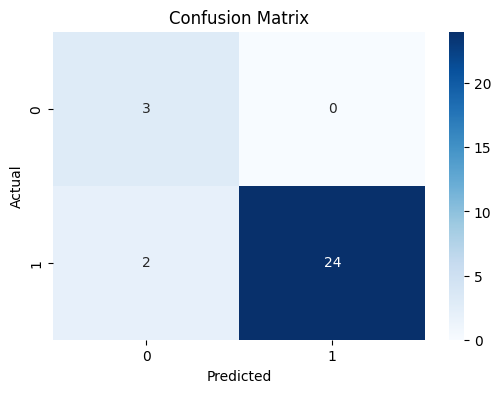

In [78]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()